In [ ]:
from dataclasses import dataclass

@dataclass
class DatasetSample:
    """Dataset sample data structure (updated categories)"""
    alpha_helix: np.ndarray
    beta_sheet: np.ndarray
    random: np.ndarray
    coils: np.ndarray
    composite: np.ndarray


def generate_sample(x_axis: np.ndarray, rng: np.random.Generator) -> DatasetSample:
    """Generate single sample with updated categories: alpha, beta_sheet, random, coils"""
    # 1) Peak counts per component
    alpha_peaks = 1
    beta_sheet_peaks = rng.integers(*BETA_SHEET_PEAKS_RANGE)
    random_peaks = rng.integers(*RANDOM_PEAKS_RANGE)
    coils_peaks = rng.integers(*COILS_PEAKS_RANGE)

    total_peaks = alpha_peaks + beta_sheet_peaks + random_peaks + coils_peaks
    print(f"Peak allocation: α={alpha_peaks}, β_sheet={beta_sheet_peaks}, random={random_peaks}, coils={coils_peaks}")
    print(f"Total peaks: {total_peaks}")

    # 2) Generate components
    # alpha
    alpha = np.zeros_like(x_axis)
    for _ in range(alpha_peaks):
        centre = ALPHA_HELIX_PEAK[0] + rng.uniform(-ALPHA_HELIX_PEAK[1], ALPHA_HELIX_PEAK[1])
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*AMP_RANGE)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        peak = _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)
        alpha += peak

    # beta_sheet (choose from two regions defined in BETA_SHEET_PEAKS)
    beta_sheet = np.zeros_like(x_axis)
    for _ in range(beta_sheet_peaks):
        center, tolerance = rng.choice(BETA_SHEET_PEAKS)
        centre = center + rng.uniform(-tolerance, tolerance)
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*AMP_RANGE)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        peak = _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)
        beta_sheet += peak

    # random
    random_comp = np.zeros_like(x_axis)
    for _ in range(random_peaks):
        centre = RANDOM_PEAK[0] + rng.uniform(-RANDOM_PEAK[1], RANDOM_PEAK[1])
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*AMP_RANGE)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        peak = _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)
        random_comp += peak

    # coils
    coils = np.zeros_like(x_axis)
    for _ in range(coils_peaks):
        centre = COILS_PEAK[0] + rng.uniform(-COILS_PEAK[1], COILS_PEAK[1])
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*AMP_RANGE)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        peak = _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)
        coils += peak

    # 3) Combine and add noise/drift
    composite_clean = alpha + beta_sheet + random_comp + coils
    baseline_drift = _generate_baseline_drift(x_axis, rng, composite_clean.max())
    composite_with_drift = composite_clean + baseline_drift
    composite_noisy = _add_realistic_noise(composite_with_drift, rng, composite_clean.max())

    return DatasetSample(
        alpha_helix=alpha,
        beta_sheet=beta_sheet,
        random=random_comp,
        coils=coils,
        composite=composite_noisy
    )


### 1. Import

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Sequence, Tuple
import os
import yaml

import numpy as np
from scipy import integrate
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load configuration file
with open("generate_dataset2.yml", 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Extract parameters from configuration
WAVENUM_MIN = config['wavenumber']['min']
WAVENUM_MAX = config['wavenumber']['max']
STEP = config['wavenumber']['step']

SUBPEAKS_RANGE = tuple(config['envelope']['subpeaks_range'])
AMP_RANGE = tuple(config['envelope']['amplitude_range'])
LORENTZ_FWHM_RANGE = tuple(config['envelope']['lorentz_fwhm_range'])

# Peak count control parameters
TOTAL_PEAKS_RANGE = tuple(config['peak_control']['total_peaks_range'])
ALPHA_HELIX_PEAKS_RANGE = tuple(config['peak_control']['component_peaks']['alpha_helix'])
BETA_SHEET_PEAKS_RANGE = tuple(config['peak_control']['component_peaks']['beta_sheet'])
RANDOM_PEAKS_RANGE = tuple(config['peak_control']['component_peaks']['random'])
COILS_PEAKS_RANGE = tuple(config['peak_control']['component_peaks']['coils'])

# Peak overlap checking parameters
CHECK_OVERLAP = config['peak_control']['validation']['check_overlap']
MIN_SEPARATION = config['peak_control']['validation']['min_separation']
ENFORCE_TOTAL = config['peak_control']['validation']['enforce_total']

GAUSS_FWHM_RANGE = tuple(config['broadening']['gauss_fwhm_range'])
DOPPLER_FWHM_RANGE = tuple(config['broadening']['doppler_fwhm_range'])

NOISE_STD_REL = config['noise']['detector_noise_std']
MICRO_PERTURBATION_STD = config['noise']['micro_perturbation_std']

BASELINE_DRIFT_AMP = config['baseline_drift']['amplitude']
BASELINE_DRIFT_PERIOD = config['baseline_drift']['period']
RANDOM_DRIFT_STD = config['baseline_drift']['random_drift_std']

# Standard peak value definitions
ALPHA_HELIX_PEAK = (config['peaks']['alpha_helix']['center'], 
                    config['peaks']['alpha_helix']['tolerance'])
BETA_SHEET_PEAKS = [tuple(peak) for peak in config['peaks']['beta_sheet']]
RANDOM_PEAK = (config['peaks']['random']['center'], 
               config['peaks']['random']['tolerance'])
COILS_PEAK = (config['peaks']['coils']['center'], 
              config['peaks']['coils']['tolerance'])

# Note: Other peaks configuration removed as we now use random and coils instead

# Dataset parameters
N_SAMPLES = config['dataset']['n_samples']
OUTPUT_FILENAME = config['dataset']['output_filename']
RANDOM_SEED = config['dataset']['random_seed']
PEAK_ALLOCATION_STRATEGY = config['dataset']['peak_allocation_strategy']
ALLOW_PEAK_ADJUSTMENT = config['dataset']['allow_peak_adjustment']

# Visualization parameters
FIGURE_SIZE = tuple(config['visualization']['figure_size'])
DPI = config['visualization']['dpi']

# Set plotting style
plt.style.use(config['visualization']['style'])
sns.set_palette(config['visualization']['palette'])

print("Configuration file loaded successfully!")
print(f"Wavenumber range: {WAVENUM_MIN} - {WAVENUM_MAX} cm⁻¹")
print(f"Wavenumber step: {STEP} cm⁻¹")
print(f"Subpeaks range: {SUBPEAKS_RANGE[0]}-{SUBPEAKS_RANGE[1]} per standard center")
print(f"Total peaks range: {TOTAL_PEAKS_RANGE[0]}-{TOTAL_PEAKS_RANGE[1]} peaks")
print(f"Random peaks range: {RANDOM_PEAKS_RANGE[0]}-{RANDOM_PEAKS_RANGE[1]} peaks")
print(f"Coils peaks range: {COILS_PEAKS_RANGE[0]}-{COILS_PEAKS_RANGE[1]} peaks")
print(f"Random peak center: {RANDOM_PEAK[0]} ± {RANDOM_PEAK[1]} cm⁻¹")
print(f"Coils peak center: {COILS_PEAK[0]} ± {COILS_PEAK[1]} cm⁻¹")
print(f"Noise level: {NOISE_STD_REL*100:.1f}%")
print(f"Number of samples to generate: {N_SAMPLES}")
print(f"Peak allocation strategy: {PEAK_ALLOCATION_STRATEGY}")


Configuration file loaded successfully!
Wavenumber range: 1570.0 - 1730.0 cm⁻¹
Wavenumber step: 0.1 cm⁻¹
Subpeaks range: 3-5 per standard center
Total peaks range: 8-15 peaks
Other peaks regions: 3 regions
Other peaks FWHM range: 6.0-12.0 cm⁻¹
Noise level: 0.8%
Number of samples to generate: 10000
Peak allocation strategy: balanced


In [3]:
# Internal utility constants
_ln2 = np.log(2.0)
FWHM_TO_SIGMA = 1.0 / (2.0 * np.sqrt(2.0 * _ln2))

def _lorentzian(x: np.ndarray, x0: float, gamma: float, amp: float) -> np.ndarray:
    """Generate Lorentzian peak."""
    half_gamma = 0.5 * gamma
    return amp * (half_gamma ** 2) / ((x - x0) ** 2 + half_gamma ** 2)

def _gaussian_kernel(sigma: float) -> np.ndarray:
    """Generate Gaussian kernel for broadening."""
    half_pts = int(np.ceil(3 * sigma / STEP))
    grid = np.arange(-half_pts, half_pts + 1) * STEP
    k = np.exp(-0.5 * (grid / sigma) ** 2)
    return k / k.sum()

def _blur(signal: np.ndarray, sigma_instr: float, sigma_dopp: float) -> np.ndarray:
    """Apply Gaussian broadening to signal."""
    sigma_tot = np.sqrt(sigma_instr ** 2 + sigma_dopp ** 2)
    return np.convolve(signal, _gaussian_kernel(sigma_tot), mode="same")


Generate simulated spectra (general function)

In [4]:
def generate_spectrum(x: np.ndarray, peak_config: dict, rng: np.random.Generator) -> np.ndarray:
    """General spectrum generation function"""
    spectrum = np.zeros_like(x)
    
    # Generate peaks
    n_peaks = rng.integers(*peak_config['count_range'])
    amp_range = peak_config['amplitude_range']
    fwhm_range = peak_config['fwhm_range']
    
    for _ in range(n_peaks):
        # Select peak position
        if 'regions' in peak_config:
            region = rng.choice(peak_config['regions'])
            centre = rng.uniform(region[0], region[1])
        elif 'centers' in peak_config:
            center, tolerance = rng.choice(peak_config['centers'])
            centre = center + rng.uniform(-tolerance, tolerance)
        else:
            centre = peak_config['center'] + rng.uniform(-peak_config['tolerance'], peak_config['tolerance'])
        
        # Generate peak parameters
        fwhm = rng.uniform(*fwhm_range)
        amp = rng.uniform(*amp_range)
        
        spectrum += _lorentzian(x, centre, fwhm, amp)
    
    # Apply broadening
    g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
    d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
    return _blur(spectrum, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)

Noise and baseline drift

In [5]:
def _generate_baseline_drift(x: np.ndarray, rng: np.random.Generator, max_amp: float) -> np.ndarray:
    """Generate realistic baseline drift."""
    # Generate multiple frequency components for realistic drift
    drift = np.zeros_like(x)
    
    # Low frequency drift (slow baseline changes)
    freq1 = 2 * np.pi / BASELINE_DRIFT_PERIOD
    phase1 = rng.uniform(0, 2 * np.pi)
    amp1 = rng.uniform(0.5, 1.0) * BASELINE_DRIFT_AMP * max_amp
    drift += amp1 * np.sin(freq1 * x + phase1)
    
    # Medium frequency drift
    freq2 = 2 * np.pi / (BASELINE_DRIFT_PERIOD * 0.5)
    phase2 = rng.uniform(0, 2 * np.pi)
    amp2 = rng.uniform(0.3, 0.7) * BASELINE_DRIFT_AMP * max_amp
    drift += amp2 * np.sin(freq2 * x + phase2)
    
    # Add some random low frequency noise
    random_drift = rng.normal(0, RANDOM_DRIFT_STD * max_amp, size=x.size)
    # Smooth random drift
    random_drift = gaussian_filter1d(random_drift, sigma=5)
    
    return drift + random_drift

def _add_realistic_noise(signal: np.ndarray, rng: np.random.Generator, max_amp: float) -> np.ndarray:
    """Add realistic noise including detector noise and micro-perturbations."""
    # Detector noise (white noise)
    detector_noise = rng.normal(0, NOISE_STD_REL * max_amp, size=signal.size)
    
    # Micro-perturbations at peak positions (simulate sampling errors)
    micro_noise = np.zeros_like(signal)
    for i in range(1, signal.size - 1):
        if signal[i] > signal[i-1] and signal[i] > signal[i+1]:  # Peak position
            # Use absolute value to ensure positive scale parameter
            perturbation_std = MICRO_PERTURBATION_STD * abs(signal[i])
            micro_noise[i] = rng.normal(0, perturbation_std)  # Micro-perturbation at peak
    
    # Combine all noise components
    return signal + detector_noise + micro_noise

In [6]:
def generate_sample(x_axis: np.ndarray, rng: np.random.Generator) -> DatasetSample:
    """Generate single sample - first determine subpeaks, then calculate total"""
    
    # 1. First determine peak counts for each component
    alpha_peaks = 1  # Fixed
    beta_sheet_peaks = rng.integers(*BETA_SHEET_PEAKS_RANGE)
    beta_turn_peaks = rng.integers(*BETA_TURN_PEAKS_RANGE)
    other_peaks = rng.integers(*OTHER_PEAKS_RANGE)
    
    # 2. Calculate total peak count
    total_peaks = alpha_peaks + beta_sheet_peaks + beta_turn_peaks + other_peaks
    
    print(f"Peak allocation: α={alpha_peaks}, β_sheet={beta_sheet_peaks}, β_turn={beta_turn_peaks}, other={other_peaks}")
    print(f"Total peaks: {total_peaks}")
    
    # 3. Generate spectral components
    alpha = np.zeros_like(x_axis)
    for _ in range(alpha_peaks):
        centre = ALPHA_HELIX_PEAK[0] + rng.uniform(-ALPHA_HELIX_PEAK[1], ALPHA_HELIX_PEAK[1])
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*AMP_RANGE)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        
        # Apply broadening
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        peak = _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)
        
        alpha += peak
    
    beta_sheet = np.zeros_like(x_axis)
    for _ in range(beta_sheet_peaks):
        center, tolerance = rng.choice(BETA_SHEET_PEAKS)
        centre = center + rng.uniform(-tolerance, tolerance)
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*AMP_RANGE)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        peak = _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)
        
        beta_sheet += peak
    
    beta_turn = np.zeros_like(x_axis)
    for _ in range(beta_turn_peaks):
        center, tolerance = rng.choice(BETA_TURN_PEAKS)
        centre = center + rng.uniform(-tolerance, tolerance)
        fwhm = rng.uniform(*LORENTZ_FWHM_RANGE)
        amp = rng.uniform(*AMP_RANGE)
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        peak = _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)
        
        beta_turn += peak
    
    other = np.zeros_like(x_axis)
    for _ in range(other_peaks):
        region = rng.choice(OTHER_PEAKS_REGIONS)
        centre = rng.uniform(region[0], region[1])
        fwhm = rng.uniform(*OTHER_PEAKS_FWHM_RANGE)
        amp = rng.uniform(AMP_RANGE[0] * OTHER_PEAKS_AMP_RATIO[0], 
                         AMP_RANGE[1] * OTHER_PEAKS_AMP_RATIO[1])
        peak = _lorentzian(x_axis, centre, fwhm, amp)
        
        g_fwhm = rng.uniform(*GAUSS_FWHM_RANGE)
        d_fwhm = rng.uniform(*DOPPLER_FWHM_RANGE)
        peak = _blur(peak, g_fwhm * FWHM_TO_SIGMA, d_fwhm * FWHM_TO_SIGMA)
        
        other += peak
    
    # 4. Combine and add noise
    composite_clean = alpha + beta_sheet + beta_turn + other
    baseline_drift = _generate_baseline_drift(x_axis, rng, composite_clean.max())
    composite_with_drift = composite_clean + baseline_drift
    composite_noisy = _add_realistic_noise(composite_with_drift, rng, composite_clean.max())
    
    return DatasetSample(
        alpha_helix=alpha,
        beta_sheet=beta_sheet,
        beta_turn=beta_turn,
        other_peaks=other,
        composite=composite_noisy
    )

In [ ]:
# Visualization with new categories
sample = generate_sample(x_axis, generator_rng)

fig, axes = plt.subplots(2, 2, figsize=FIGURE_SIZE, dpi=DPI)
fig.suptitle('Synthetic Spectrum Sample Check (updated)', fontsize=16, fontweight='bold')

axes[0, 0].plot(x_axis, sample.alpha_helix, label='α-helix', linewidth=2)
axes[0, 0].plot(x_axis, sample.beta_sheet, label='β-sheet', linewidth=2)
axes[0, 0].plot(x_axis, sample.random, label='Random', linewidth=2)
axes[0, 0].plot(x_axis, sample.coils, label='Coils', linewidth=2)
axes[0, 0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0, 0].set_ylabel('Intensity')
axes[0, 0].set_title('Spectral Components')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Clean composite spectrum
composite_clean = sample.alpha_helix + sample.beta_sheet + sample.random + sample.coils
axes[0, 1].plot(x_axis, composite_clean, label='Clean composite spectrum', linewidth=2, color='blue')
axes[0, 1].set_xlabel('Wavenumber (cm⁻¹)')
axes[0, 1].set_ylabel('Intensity')
axes[0, 1].set_title('Clean Composite Spectrum')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Noisy composite spectrum
axes[1, 0].plot(x_axis, sample.composite, label='Noisy composite spectrum', linewidth=2, color='red')
axes[1, 0].plot(x_axis, composite_clean, label='Clean composite spectrum', linewidth=1, color='blue', alpha=0.7)
axes[1, 0].set_xlabel('Wavenumber (cm⁻¹)')
axes[1, 0].set_ylabel('Intensity')
axes[1, 0].set_title('Noisy vs Clean Composite Spectrum')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Noise analysis
noise = sample.composite - composite_clean
axes[1, 1].plot(x_axis, noise, label='Noise', linewidth=1, color='gray')
axes[1, 1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1, 1].set_ylabel('Noise Intensity')
axes[1, 1].set_title(f'Noise Analysis (RMS: {np.sqrt(np.mean(noise**2)):.4f})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Sample generation completed!')
print(f"Component intensities: α={np.max(sample.alpha_helix):.3f}, β={np.max(sample.beta_sheet):.3f}, random={np.max(sample.random):.3f}, coils={np.max(sample.coils):.3f}")
print(f"Composite spectrum intensities: clean={np.max(composite_clean):.3f}, noisy={np.max(sample.composite):.3f}")


In [ ]:
# Generate full dataset with new categories and save
from datetime import datetime

print(f"Generating {N_SAMPLES} samples (updated categories)...")

alpha_all = np.zeros((N_SAMPLES, len(x_axis)))
beta_sheet_all = np.zeros((N_SAMPLES, len(x_axis)))
random_all = np.zeros((N_SAMPLES, len(x_axis)))
coils_all = np.zeros((N_SAMPLES, len(x_axis)))
composite_all = np.zeros((N_SAMPLES, len(x_axis)))

for i in range(N_SAMPLES):
    if i % 1000 == 0:
        print(f"Generated {i}/{N_SAMPLES} samples...")
    
    sample = generate_sample(x_axis, generator_rng)
    
    alpha_all[i] = sample.alpha_helix
    beta_sheet_all[i] = sample.beta_sheet
    random_all[i] = sample.random
    coils_all[i] = sample.coils
    composite_all[i] = sample.composite

# Save dataset with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_filename = OUTPUT_FILENAME.replace('.npz', '')
filename = f"{base_filename}_{timestamp}.npz"
save_path = os.path.join('../data', filename)

np.savez(save_path,
         wavenumber_axis=x_axis,
         alpha_helix=alpha_all,
         beta_sheet=beta_sheet_all,
         random=random_all,
         coils=coils_all,
         composite=composite_all)

print("=" * 50)
print("Dataset generation completed (updated)!")
print(f"File location: {save_path}")
print(f"File size: {os.path.getsize(save_path) / (1024*1024):.1f} MB")
print(f"Dataset shape: {N_SAMPLES} samples × {len(x_axis)} spectral points")
print("=" * 50)


In [7]:
from dataclasses import dataclass

@dataclass
class DatasetSample:
    """Dataset sample data structure"""
    alpha_helix: np.ndarray
    beta_sheet: np.ndarray
    beta_turn: np.ndarray
    other_peaks: np.ndarray
    composite: np.ndarray

# Initialize wavenumber axis and random number generator
x_axis = np.arange(WAVENUM_MIN, WAVENUM_MAX + STEP, STEP)

if RANDOM_SEED is None or str(RANDOM_SEED).lower() in ['none', 'null', '']:
    generator_rng = np.random.default_rng()
    print("Using random seed")
else:
    try:
        # Try to convert to integer
        seed_value = int(RANDOM_SEED)
        generator_rng = np.random.default_rng(seed_value)
        print(f"Using fixed random seed: {seed_value}")
    except (ValueError, TypeError):
        # If conversion fails, use random seed
        generator_rng = np.random.default_rng()
        print(f"Seed value '{RANDOM_SEED}' is invalid, using random seed")

print(f"Wavenumber axis length: {len(x_axis)}")
print(f"Wavenumber range: {x_axis.min():.1f} - {x_axis.max():.1f} cm⁻¹")

Using random seed
Wavenumber axis length: 1601
Wavenumber range: 1570.0 - 1730.0 cm⁻¹


Peak allocation: α=1, β_sheet=2, β_turn=2, other=5
Total peaks: 10


/var/folders/_p/nn9gm6dx5l1c43zg9v3kwwch0000gn/T/ipykernel_33429/2853437525.py:46: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/weianqi/Desktop/Photothermal Spectroscopy Deconvolution/spectral segmentation/spectral_segmentation/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


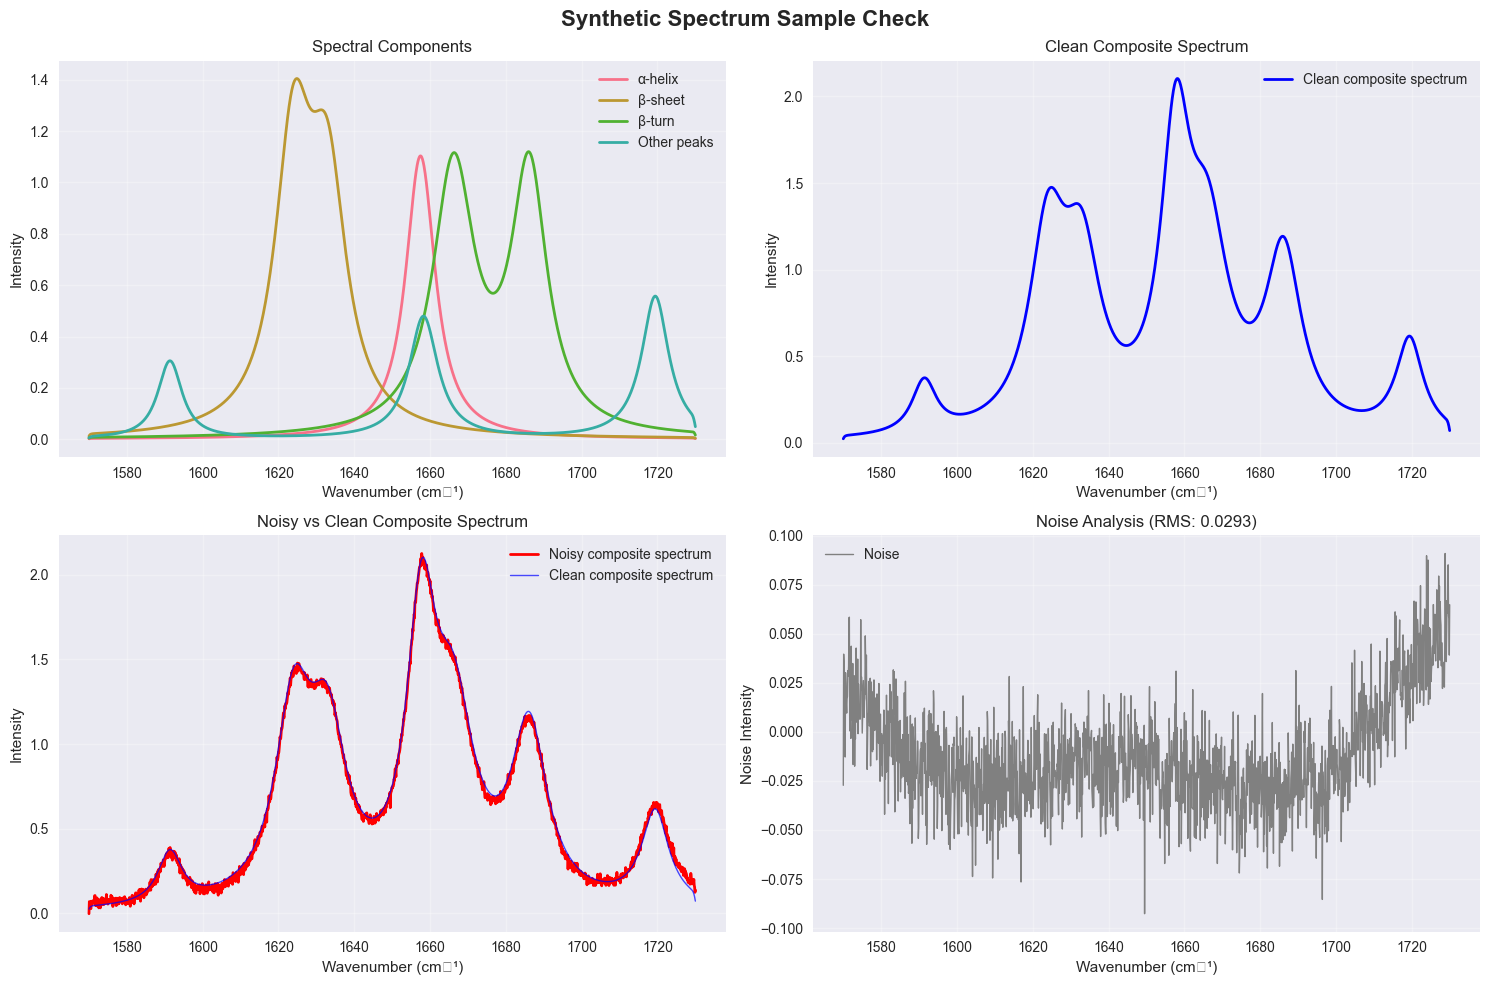

Sample generation completed!
Component intensities: α=1.103, β=1.405, β_turn=1.120
Composite spectrum intensities: clean=2.103, noisy=2.126


In [8]:
# Visualization check - generate single sample
sample = generate_sample(x_axis, generator_rng)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=FIGURE_SIZE, dpi=DPI)
fig.suptitle('Synthetic Spectrum Sample Check', fontsize=16, fontweight='bold')

# Spectral components
axes[0, 0].plot(x_axis, sample.alpha_helix, label='α-helix', linewidth=2)
axes[0, 0].plot(x_axis, sample.beta_sheet, label='β-sheet', linewidth=2)
axes[0, 0].plot(x_axis, sample.beta_turn, label='β-turn', linewidth=2)
axes[0, 0].plot(x_axis, sample.other_peaks, label='Other peaks', linewidth=2)
axes[0, 0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0, 0].set_ylabel('Intensity')
axes[0, 0].set_title('Spectral Components')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Clean composite spectrum
composite_clean = sample.alpha_helix + sample.beta_sheet + sample.beta_turn + sample.other_peaks
axes[0, 1].plot(x_axis, composite_clean, label='Clean composite spectrum', linewidth=2, color='blue')
axes[0, 1].set_xlabel('Wavenumber (cm⁻¹)')
axes[0, 1].set_ylabel('Intensity')
axes[0, 1].set_title('Clean Composite Spectrum')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Noisy composite spectrum
axes[1, 0].plot(x_axis, sample.composite, label='Noisy composite spectrum', linewidth=2, color='red')
axes[1, 0].plot(x_axis, composite_clean, label='Clean composite spectrum', linewidth=1, color='blue', alpha=0.7)
axes[1, 0].set_xlabel('Wavenumber (cm⁻¹)')
axes[1, 0].set_ylabel('Intensity')
axes[1, 0].set_title('Noisy vs Clean Composite Spectrum')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Noise analysis
noise = sample.composite - composite_clean
axes[1, 1].plot(x_axis, noise, label='Noise', linewidth=1, color='gray')
axes[1, 1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1, 1].set_ylabel('Noise Intensity')
axes[1, 1].set_title(f'Noise Analysis (RMS: {np.sqrt(np.mean(noise**2)):.4f})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Sample generation completed!")
print(f"Component intensities: α={np.max(sample.alpha_helix):.3f}, β={np.max(sample.beta_sheet):.3f}, β_turn={np.max(sample.beta_turn):.3f}")
print(f"Composite spectrum intensities: clean={np.max(composite_clean):.3f}, noisy={np.max(sample.composite):.3f}")

In [ ]:
# Generate dataset
print(f"Generating {N_SAMPLES} samples...")

# Initialize arrays
alpha_all = np.zeros((N_SAMPLES, len(x_axis)))
beta_sheet_all = np.zeros((N_SAMPLES, len(x_axis)))
beta_turn_all = np.zeros((N_SAMPLES, len(x_axis)))
other_all = np.zeros((N_SAMPLES, len(x_axis)))
composite_all = np.zeros((N_SAMPLES, len(x_axis)))

for i in range(N_SAMPLES):
    if i % 1000 == 0:
        print(f"Generated {i}/{N_SAMPLES} samples...")
    
    # Directly use the existing generate_sample function
    sample = generate_sample(x_axis, generator_rng)
    
    # Store to arrays
    alpha_all[i] = sample.alpha_helix
    beta_sheet_all[i] = sample.beta_sheet
    beta_turn_all[i] = sample.beta_turn
    other_all[i] = sample.other_peaks
    composite_all[i] = sample.composite

# Save dataset
from datetime import datetime

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_filename = OUTPUT_FILENAME.replace('.npz', '')
filename = f"{base_filename}_{timestamp}.npz"

# Save to data folder
save_path = os.path.join('../data', filename)
np.savez(save_path, 
         wavenumber_axis=x_axis,
         alpha_helix=alpha_all,
         beta_sheet=beta_sheet_all,
         beta_turn=beta_turn_all,
         other_peaks=other_all,
         composite=composite_all)

print("=" * 50)
print("Dataset generation completed!")
print(f"File location: {save_path}")
print(f"File size: {os.path.getsize(save_path) / (1024*1024):.1f} MB")
print(f"Dataset shape: {N_SAMPLES} samples × {len(x_axis)} spectral points")
print("=" * 50)

正在生成 10000 个样本...
已生成 0/10000 个样本...
峰数分配: α=1, β_sheet=2, β_turn=2, other=4
总峰数: 9
峰数分配: α=1, β_sheet=3, β_turn=2, other=5
总峰数: 11
峰数分配: α=1, β_sheet=3, β_turn=1, other=5
总峰数: 10
峰数分配: α=1, β_sheet=3, β_turn=1, other=6
总峰数: 11
峰数分配: α=1, β_sheet=2, β_turn=1, other=4
总峰数: 8
峰数分配: α=1, β_sheet=2, β_turn=2, other=4
总峰数: 9
峰数分配: α=1, β_sheet=3, β_turn=2, other=6
总峰数: 12
峰数分配: α=1, β_sheet=3, β_turn=1, other=6
总峰数: 11
峰数分配: α=1, β_sheet=3, β_turn=1, other=6
总峰数: 11
峰数分配: α=1, β_sheet=2, β_turn=1, other=5
总峰数: 9
峰数分配: α=1, β_sheet=3, β_turn=1, other=5
总峰数: 10
峰数分配: α=1, β_sheet=2, β_turn=2, other=6
总峰数: 11
峰数分配: α=1, β_sheet=3, β_turn=1, other=4
总峰数: 9
峰数分配: α=1, β_sheet=3, β_turn=1, other=5
总峰数: 10
峰数分配: α=1, β_sheet=2, β_turn=2, other=6
总峰数: 11
峰数分配: α=1, β_sheet=2, β_turn=1, other=4
总峰数: 8
峰数分配: α=1, β_sheet=2, β_turn=1, other=4
总峰数: 8
峰数分配: α=1, β_sheet=2, β_turn=2, other=6
总峰数: 11
峰数分配: α=1, β_sheet=3, β_turn=1, other=6
总峰数: 11
峰数分配: α=1, β_sheet=3, β_turn=1, other=4
总峰数: 9
峰数分配: α=1, 

KeyboardInterrupt: 